# Exercise (Normal Distribution and Z Score for Outlier Removal)

You are given bhp.csv which contains property prices in the city of banglore, India. You need to examine price_per_sqft column and do following,

Remove outliers using percentile technique first. Use [0.001, 0.999] for lower and upper bound percentiles\
After removing outliers in step 1, you get a new dataframe.\
On step(2) dataframe, use 4 standard deviation to remove outliers\
Plot histogram for new dataframe that is generated after step (3). Also plot bell curve on same histogram\
On step(2) dataframe, use zscore of 4 to remove outliers. This is quite similar to step (3) and you will get exact same result

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("bhp.csv")
print(df.head())
print(df.shape)

df.price_per_sqft.quantile([0.001, 0.25, 0.5, 0.75 ,0.999])


                   location       size  total_sqft  bath   price  bhk  \
0  Electronic City Phase II      2 BHK      1056.0   2.0   39.07    2   
1          Chikka Tirupathi  4 Bedroom      2600.0   5.0  120.00    4   
2               Uttarahalli      3 BHK      1440.0   2.0   62.00    3   
3        Lingadheeranahalli      3 BHK      1521.0   3.0   95.00    3   
4                  Kothanur      2 BHK      1200.0   2.0   51.00    2   

   price_per_sqft  
0            3699  
1            4615  
2            4305  
3            6245  
4            4250  
(13200, 7)


0.001     1366.184
0.250     4267.000
0.500     5438.000
0.750     7317.000
0.999    50959.362
Name: price_per_sqft, dtype: float64

In [13]:
df2 =  df[(df.price_per_sqft < df.price_per_sqft.quantile(0.999)) & (df.price_per_sqft > df.price_per_sqft.quantile(0.001))]
print(df2.shape)

(13172, 7)


In [14]:
#print(df2.price_per_sqft.describe())
df3 = df2[(df2.price_per_sqft < 6663.653735 + 4*4141.020700000001) & (df2.price_per_sqft > 6663.653735 - 4*4141.020700000001)]
print(df3.shape)

(13047, 7)


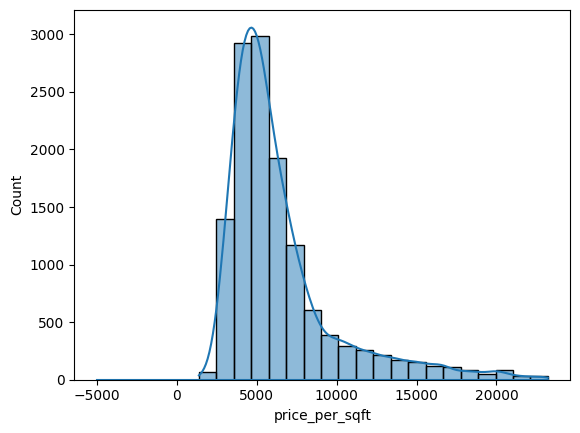

In [30]:
from scipy.stats import norm
%matplotlib inline
sns.histplot(df3.price_per_sqft, kde=True ,bins=20 )

rng = np.arange(-5000, df3.price_per_sqft.max(), 100)
plt.plot(rng, norm.pdf(rng,df3.price_per_sqft.mean(),df3.price_per_sqft.std()))

plt.show()

In [21]:
df2["z_score"] = (df2.price_per_sqft - df2.price_per_sqft.mean())/df2.price_per_sqft.std()
df4 = df2[df2.z_score.between(-4, 4)]
print(df4.shape)

(13047, 8)
